## 1. Data Ingestion & Initial Exploration
Fetching the raw transaction dataset from the UCI Machine Learning Repository to inspect the initial structure and dimensions.

In [ ]:
import pandas as pd

# URL for the real-world dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

print("Dataset downloading wait- a few minutes")
df = pd.read_excel(url)

print("Data successfully loaded!")
print(f"Dataset Size: {df.shape[0]} rows and {df.shape[1]} columns.")

# View the first 5 rows of the data
df.head()

Dataset downloading wait- a few minutes
Data successfully loaded!
Dataset Size: 541909 rows and 8 columns.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Data Cleaning & Preprocessing

### Identifying Missing Values
To check missing `CustomerID` records that cannot be attributed to specific customer profiles.

In [ ]:
missing_customers = df['CustomerID'].isnull().sum()
print(f"Missing Customer IDs before cleaning: {missing_customers}")

Missing Customer IDs before cleaning: 135080


### Removing Missing Customer Identifiers
Droping rows where `CustomerID` is null to ensure every transaction links directly to a unique user.

In [ ]:
df_clean = df.dropna(subset=['CustomerID'])

### Filtering Invalid Transactions
Remove negative or zero values in `Quantity` and `UnitPrice` to eliminate returns, cancellations, and corrupted system records.

In [ ]:
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
# Filter out non-positive quantities to drop cancellations and damaged items

### Feature Creation: Line-Item Revenue
Calculate `TotalPrice` for each line item by multiplying `Quantity` by `UnitPrice`.

In [ ]:
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

### Data Type Formatting
Cast `CustomerID` to integer to remove unnecessary floating-point decimals.

In [ ]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

### Summary Verification
Inspect the final cleaned dataset size to verify how many invalid records were filtered out.

In [ ]:
print("\n--- Cleaning Complete ---")
print(f"Original Dataset Size: {df.shape[0]} rows")
print(f"Cleaned Dataset Size: {df_clean.shape[0]} rows")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")


--- Cleaning Complete ---
Original Dataset Size: 541909 rows
Cleaned Dataset Size: 397884 rows
Rows removed: 144025


### Cleaned Data Verification
Preview key columns of the cleaned dataframe to confirm calculations like `TotalPrice` were generated correctly.

In [ ]:
df_clean[['CustomerID', 'InvoiceNo', 'Quantity', 'UnitPrice', 'TotalPrice']].head()

,CustomerID,InvoiceNo,Quantity,UnitPrice,TotalPrice
0,17850,536365,6,2.55,15.30
1,17850,536365,6,3.39,20.34
2,17850,536365,8,2.75,22.00
3,17850,536365,6,3.39,20.34
4,17850,536365,6,3.39,20.34


## 3. Feature Engineering: RFM Segmentation

### Import Datetime Library
Load the datetime module to perform date arithmetic for customer recency calculations.

In [ ]:
import datetime as dt

### Define Reference Date
Set a reference snapshot date (one day after the latest transaction) to treat as "today" for measuring how recently customers bought items.

In [ ]:
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
print(f"Snapshot Date (Treating this as 'Today'): {snapshot_date.date()}\n")

Snapshot Date (Treating this as 'Today'): 2011-12-10



### Aggregate Customer Metrics
Group dataset by `CustomerID` and aggregate raw transaction data into Recency, Frequency, and Monetary metrics:
- **Recency:** Days since last purchase.
- **Frequency:** Count of unique invoice numbers.
- **Monetary:** Sum of total expenditure.

In [ ]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Days since last purchase
    'InvoiceNo': 'nunique',                                  # Number of unique orders
    'TotalPrice': 'sum'                                      # Total money spent
})

### Rename Columns & Inspect Profiles
Rename aggregated columns to `Recency`, `Frequency`, and `Monetary`, then preview the newly generated customer profiles.

In [ ]:
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

print("--- RFM Profiles Created ---")
print(f"Total Unique Customers: {rfm.shape[0]}")
rfm.head()

--- RFM Profiles Created ---
Total Unique Customers: 4338


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


### Exporting RFM Profiles to Interactive Sheet
Export the aggregated RFM dataframe to Google Sheets for interactive viewing and sharing.

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=rfm)

https://docs.google.com/spreadsheets/d/1vCveU8h8chPY0XNejW0MWUNpASRQwMNhddStaE4Qvwg/edit#gid=0


## 4. Churn Target Definition

### Defining Churn Threshold & Calculating Distribution
Create the binary target variable `Churn` based on a **90-day inactivity threshold** (`1` = Churned, `0` = Active) and analyze the dataset's class distribution.

In [ ]:
# 1. Define the churn threshold (90 days)
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)

# 2. Check the percentage breakdown of Churned vs. Active customers
churn_counts = rfm['Churn'].value_counts()
churn_percentage = rfm['Churn'].value_counts(normalize=True) * 100

print("--- Churn Label Breakdown ---")
print(f"Active Customers (0): {churn_counts[0]} ({churn_percentage[0]:.2f}%)")
print(f"Churned Customers (1): {churn_counts[1]} ({churn_percentage[1]:.2f}%)")

--- Churn Label Breakdown ---
Active Customers (0): 2889 (66.60%)
Churned Customers (1): 1449 (33.40%)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

### Visualizing Churn Distribution & Customer Spending
Generate a dual-panel dashboard:
- **Pie Chart:** Highlights the proportion of Active vs. Churned customers.
- **Log-Scaled Scatter Plot:** Analyzes the relationship between purchase frequency and monetary spend using a minimalist, high-contrast palette.

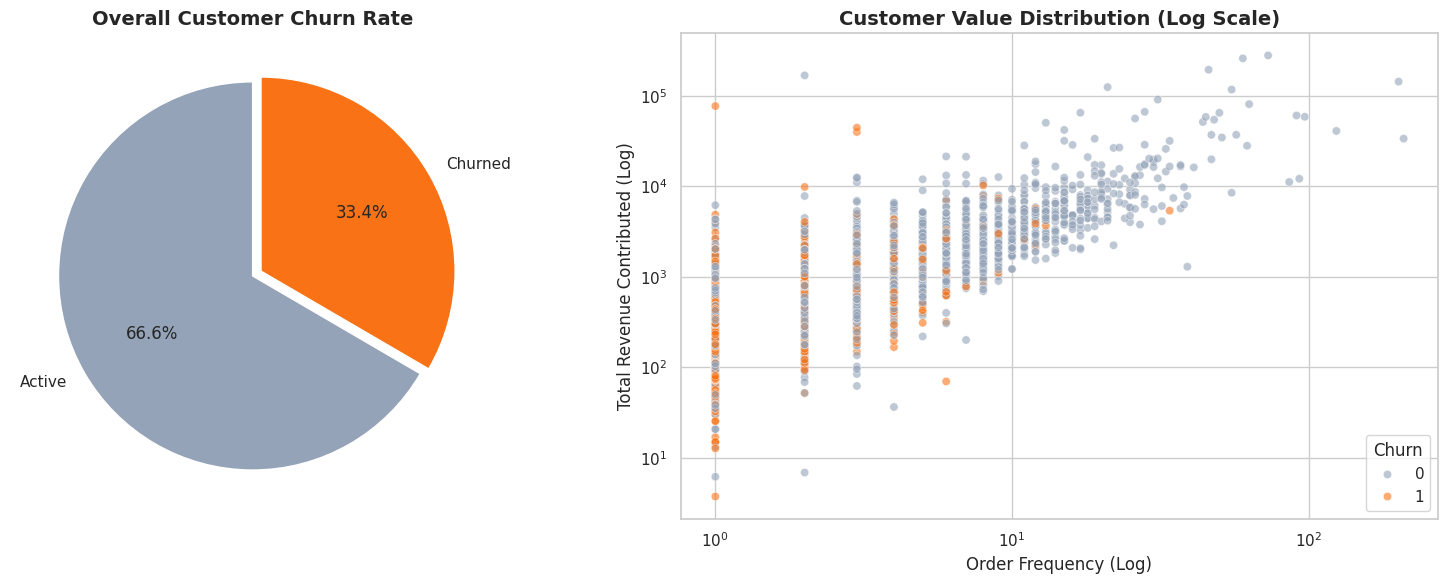

In [ ]:
# Set style for the plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Pie Chart for Churn Rate
axes[0].pie(churn_counts, labels=['Active', 'Churned'], autopct='%1.1f%%',
            startangle=90, colors=['#94A3B8', '#F97316'], explode=(0, 0.05))
axes[0].set_title('Overall Customer Churn Rate', fontsize=14, fontweight='bold')

# Chart 2: Scatter Plot (Frequency vs Monetary Value)
# We use log scale because some corporate customers spend massive amounts, distorting the axis
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Churn',
                palette=['#94A3B8', '#F97316'], alpha=0.6, ax=axes[1])
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Customer Value Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Order Frequency (Log)')
axes[1].set_ylabel('Total Revenue Contributed (Log)')

plt.tight_layout()
plt.show()

## 6. Baseline Model Development

### Model Training & Initial Evaluation
Train a baseline **Random Forest Classifier** using raw Frequency and Monetary features to establish a benchmark performance score.

*Note: Recency is intentionally dropped to prevent data leakage, as Churn was derived directly from it.*

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Separate our features (X) from our target label (y)
# We drop 'Recency' because 'Churn' was literally created from it.
# Keeping it would be "data leakage" (cheating for the model).
X = rfm[['Frequency', 'Monetary']]
y = rfm['Churn']

# 2. Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} customers")
print(f"Testing set size: {X_test.shape[0]} customers")

# 3. Initialize and train the Random Forest model
print("\nTraining the Random Forest model... please wait...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Make predictions on the hidden test set
y_pred = model.predict(X_test)

# 5. Evaluate how well the model performed
accuracy = accuracy_score(y_test, y_pred)
print("\n--- Model Evaluation ---")
print(f"Overall Model Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

Training set size: 3470 customers
Testing set size: 868 customers

Training the Random Forest model... please wait...

--- Model Evaluation ---
Overall Model Accuracy: 64.52%

Detailed Performance Report:
              precision    recall  f1-score   support

      Active       0.73      0.75      0.74       578
     Churned       0.47      0.43      0.45       290

    accuracy                           0.65       868
   macro avg       0.60      0.59      0.59       868
weighted avg       0.64      0.65      0.64       868



## 7. Model Optimization & Feature Engineering

### Feature Engineering & Balanced Training
Engineer `AvgOrderValue` and retrain the Random Forest model with `class_weight='balanced'` to evaluate performance improvements against the baseline model.

In [ ]:
# 1. Create a new feature: Average Order Value
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

# 2. Update our feature list to include the new column
X = rfm[['Frequency', 'Monetary', 'AvgOrderValue']]
y = rfm['Churn']

# 3. Split the data again
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Retrain the model with a balance adjustment
# 'class_weight="balanced"' tells the model to pay extra attention to the smaller Churned group!
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model_improved = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_improved.fit(X_train, y_train)

# 5. Predict and evaluate
y_pred_improved = model_improved.predict(X_test)

print("--- Updated Model Evaluation ---")
print(classification_report(y_test, y_pred_improved, target_names=['Active', 'Churned']))

--- Updated Model Evaluation ---
              precision    recall  f1-score   support

      Active       0.73      0.75      0.74       578
     Churned       0.47      0.44      0.45       290

    accuracy                           0.65       868
   macro avg       0.60      0.60      0.60       868
weighted avg       0.64      0.65      0.64       868



## 8. Deployment & Inference Pipeline

### Real-Time Customer Churn Risk Inference
Define a custom inference function `predict_customer_churn()` that accepts raw behavioral inputs, computes required feature transformations, and outputs real-time churn predictions with probability scores.

In [ ]:
def predict_customer_churn(frequency, total_monetary):
    """
    Function to predict churn probability for a single customer.
    Inputs:
    - frequency: Total number of orders placed
    - total_monetary: Total money spent ($)
    """
    # Calculate the average order value feature
    avg_order_value = total_monetary / frequency if frequency > 0 else 0

    # Create input dataframe matching our model's features
    input_data = pd.DataFrame({
        'Frequency': [frequency],
        'Monetary': [total_monetary],
        'AvgOrderValue': [avg_order_value]
    })

    # Get prediction and probability from our improved model
    prediction = model_improved.predict(input_data)[0]
    churn_probability = model_improved.predict_proba(input_data)[0][1] * 100

    print("=" * 45)
    print(f"📊 CUSTOMER RISK PROFILE")
    print("=" * 45)
    print(f"Order Frequency: {frequency} orders")
    print(f"Total Money Spent: ${total_monetary:,.2f}")
    print(f"Average Spend per Order: ${avg_order_value:,.2f}")
    print("-" * 45)
    print(f"Predicted Status: {'⚠️ CHURN RISK' if prediction == 1 else '✅ ACTIVE / SAFE'}")
    print(f"Probability of Churning: {churn_probability:.1f}%")
    print("=" * 45)

# --- TEST IT OUT WITH SAMPLE CUSTOMERS ---

# Customer A: Bought 25 times and spent $5,000
predict_customer_churn(frequency=25, total_monetary=5000)

print("\n")

# Customer B: Bought 1 time and spent $15
predict_customer_churn(frequency=1, total_monetary=15)

📊 CUSTOMER RISK PROFILE
Order Frequency: 25 orders
Total Money Spent: $5,000.00
Average Spend per Order: $200.00
---------------------------------------------
Predicted Status: ✅ ACTIVE / SAFE
Probability of Churning: 0.0%


📊 CUSTOMER RISK PROFILE
Order Frequency: 1 orders
Total Money Spent: $15.00
Average Spend per Order: $15.00
---------------------------------------------
Predicted Status: ⚠️ CHURN RISK
Probability of Churning: 92.0%
